# Train / Test Split

**Input**: `data/processed/merged_inspections_licenses_inner_clean.parquet`  
**Output**:
- `data/processed/train.parquet` / `train.csv`
- `data/processed/test.parquet` / `test.csv`

## Strategy: Temporal Split

Food inspections are **time-series events** — a model trained on this data will be used to
predict *future* inspection outcomes. A random split would leak future information into the
training set. Instead, we split on `Inspection Date`:

- **Train**: inspections before the cutoff date  
- **Test**: inspections on or after the cutoff date

The cutoff is chosen so that ~80% of rows fall in train and ~20% in test.

In [1]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

from helpers.data_loader import DataLoader

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

# ── Paths ──────────────────────────────────────────────────────────
INPUT_PATH   = DataLoader.processed('merged_inspections_licenses_inner_clean.parquet')
TRAIN_CSV    = DataLoader.processed('train.csv')
TRAIN_PARQ   = DataLoader.processed('train.parquet')
TEST_CSV     = DataLoader.processed('test.csv')
TEST_PARQ    = DataLoader.processed('test.parquet')

# ── Config ─────────────────────────────────────────────────────────
TARGET_COL      = 'Results'
DATE_COL        = 'Inspection Date'
ID_COL          = 'Inspection ID'
TEST_FRACTION   = 0.20          # target fraction for the test set
RANDOM_STATE    = 42

## 1 · Load cleaned data

In [2]:
df = pd.read_parquet(INPUT_PATH)
print('Loaded shape:', df.shape)
print('Columns:', list(df.columns))
df.head(3)

Loaded shape: (171601, 58)
Columns: ['Unnamed: 0', 'Inspection ID', 'DBA Name', 'AKA Name', 'License #', 'Facility Type', 'Risk', 'Address', 'Zip', 'Inspection Date', 'Inspection Type', 'Results', 'Violations', 'Latitude', 'Longitude', 'BL_ID', 'BL_LICENSE_ID', 'ACCOUNT NUMBER', 'SITE NUMBER', 'BL_LEGAL_NAME', 'BL_DBA_NAME', 'BL_ADDRESS', 'BL_CITY', 'BL_STATE', 'BL_ZIP_CODE', 'WARD', 'PRECINCT', 'WARD PRECINCT', 'POLICE DISTRICT', 'COMMUNITY AREA', 'COMMUNITY AREA NAME', 'NEIGHBORHOOD', 'LICENSE CODE', 'LICENSE DESCRIPTION', 'BUSINESS ACTIVITY ID', 'BUSINESS ACTIVITY', 'LICENSE NUMBER', 'APPLICATION TYPE', 'APPLICATION CREATED DATE', 'APPLICATION REQUIREMENTS COMPLETE', 'PAYMENT DATE', 'CONDITIONAL APPROVAL', 'LICENSE TERM START DATE', 'LICENSE TERM EXPIRATION DATE', 'LICENSE APPROVED FOR ISSUANCE', 'DATE ISSUED', 'LICENSE STATUS', 'LICENSE STATUS CHANGE DATE', 'SSA', 'BL_LATITUDE', 'BL_LONGITUDE', 'BL_LOCATION', 'flag_non_il_state', 'flag_non_chicago_city', 'flag_longitude_outside_typ

,Unnamed: 0,Inspection ID,DBA Name,AKA Name,License #,Facility Type,Risk,Address,Zip,Inspection Date,Inspection Type,Results,Violations,Latitude,Longitude,BL_ID,BL_LICENSE_ID,ACCOUNT NUMBER,SITE NUMBER,BL_LEGAL_NAME,BL_DBA_NAME,BL_ADDRESS,BL_CITY,BL_STATE,BL_ZIP_CODE,WARD,PRECINCT,WARD PRECINCT,POLICE DISTRICT,COMMUNITY AREA,COMMUNITY AREA NAME,NEIGHBORHOOD,LICENSE CODE,LICENSE DESCRIPTION,BUSINESS ACTIVITY ID,BUSINESS ACTIVITY,LICENSE NUMBER,APPLICATION TYPE,APPLICATION CREATED DATE,APPLICATION REQUIREMENTS COMPLETE,PAYMENT DATE,CONDITIONAL APPROVAL,LICENSE TERM START DATE,LICENSE TERM EXPIRATION DATE,LICENSE APPROVED FOR ISSUANCE,DATE ISSUED,LICENSE STATUS,LICENSE STATUS CHANGE DATE,SSA,BL_LATITUDE,BL_LONGITUDE,BL_LOCATION,flag_non_il_state,flag_non_chicago_city,flag_longitude_outside_typical_range,violations_recorded,license_matched,has_prior_inspection
0,0,2352683,CHIPOTLE MEXICAN GRILL,CHIPOTLE MEXICAN GRILL,2670642.0,Restaurant,High,1025 W ADDISON ST,60613.0,2019-12-04,License Re-Inspection,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.947118,-87.655381,2670642-20250516,3016570.0,22633.0,43.0,"CHIPOTLE MEXICAN GRILL, INC.",CHIPOTLE MEXICAN GRILL #3433,1017 W ADDISON ST 1ST A201,CHICAGO,IL,60613.0,44.0,38.0,44-38,19.0,6.0,LAKE VIEW,WRIGLEYVILLE,1006.0,Retail Food Establishment,735,Preparation of Food and Dining on Premises Wit...,2670642.0,RENEW,NaN,2025-03-15,2025-04-01,N,NaN,2027-05-15,2025-04-01,2025-04-02,AAI,NaN,17.0,41.947123,-87.655066,"(41.947122592189345, -87.65506631884556)",False,False,False,True,True,True
1,1,2352734,CHILI'S T-I,CHILI'S (T1-B14),34169.0,Restaurant,High,11601 W TOUHY AVE,60666.0,2019-12-04,Canvass,Pass,10. ADEQUATE HANDWASHING SINKS PROPERLY SUPPLI...,42.008536,-87.914428,34169-20241016,2984151.0,1896.0,17.0,"HOST INTERNATIONAL, INC.",CHILI'S T-I,"11601 W TOUHY AVE # B04,T",CHICAGO,IL,60666.0,41.0,27.0,41-27,16.0,76.0,OHARE,O'HARE,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,34169.0,RENEW,NaN,2024-08-15,2024-09-10,N,NaN,2026-10-15,2024-09-10,2024-09-11,AAI,NaN,NaN,42.008751,-87.906874,"(42.00875076599798, -87.90687413400109)",False,False,False,True,True,True
2,3,2352701,TAQUERIA BLUE LINE INC.,NaN,2703436.0,Restaurant,High,3401 W BELMONT AVE,60618.0,2019-12-04,License,Pass w/ Conditions,"3. MANAGEMENT, FOOD EMPLOYEE AND CONDITIONAL E...",41.939168,-87.712546,2703436-20260116,3059441.0,464457.0,1.0,TAQUERIA BLUE LINE INC.,MIC DUCK'S,3401 W BELMONT AVE,CHICAGO,IL,60618.0,35.0,24.0,35-24,14.0,21.0,AVONDALE,AVONDALE,1006.0,Retail Food Establishment,735,Preparation of Food and Dining on Premises Wit...,2703436.0,RENEW,NaN,2025-11-15,2026-01-07,N,NaN,2028-01-15,2026-01-07,2026-01-08,AAI,NaN,NaN,41.939168,-87.712546,"(41.93916783376966, -87.71254599117191)",False,False,False,True,True,False


## 2 · Parse & validate Inspection Date

In [3]:
df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors='coerce')

null_dates = df[DATE_COL].isna().sum()
print(f'Null dates: {null_dates}  ({null_dates / len(df) * 100:.2f}%)')

if null_dates > 0:
    print('Dropping rows with null Inspection Date (cannot place in time).')
    df = df.dropna(subset=[DATE_COL]).copy()
    print(f'Shape after dropping null dates: {df.shape}')

print(f'Date range: {df[DATE_COL].min().date()}  →  {df[DATE_COL].max().date()}')

Null dates: 0  (0.00%)
Date range: 2010-01-04  →  2019-12-04


## 3 · Compute temporal cutoff

In [4]:
# Sort by date to find the cutoff that gives ~80/20 split
df = df.sort_values(DATE_COL).reset_index(drop=True)

cutoff_idx  = int(len(df) * (1 - TEST_FRACTION))
cutoff_date = df.loc[cutoff_idx, DATE_COL]

print(f'Cutoff index : {cutoff_idx:,}')
print(f'Cutoff date  : {cutoff_date.date()}')
print(f'Rows before  : {cutoff_idx:,}  ({cutoff_idx / len(df) * 100:.1f}%)')
print(f'Rows on/after: {len(df) - cutoff_idx:,}  ({(len(df) - cutoff_idx) / len(df) * 100:.1f}%)')

Cutoff index : 137,280
Cutoff date  : 2017-08-31
Rows before  : 137,280  (80.0%)
Rows on/after: 34,321  (20.0%)


## 4 · Split

In [5]:
train_mask = df[DATE_COL] < cutoff_date
test_mask  = ~train_mask

df_train = df.loc[train_mask].copy()
df_test  = df.loc[test_mask].copy()

print(f'Train : {len(df_train):>7,} rows  ({len(df_train)/len(df)*100:.1f}%)')
print(f'Test  : {len(df_test):>7,} rows  ({len(df_test)/len(df)*100:.1f}%)')
print(f'Total : {len(df):>7,} rows')

# Sanity: no overlap
assert df_train[DATE_COL].max() < df_test[DATE_COL].min(), \
    'Data leakage detected — train dates overlap with test dates!'
print(f'\n No temporal overlap  (train max: {df_train[DATE_COL].max().date()}, '
      f'test min: {df_test[DATE_COL].min().date()})')

Train : 137,235 rows  (80.0%)
Test  :  34,366 rows  (20.0%)
Total : 171,601 rows

 No temporal overlap  (train max: 2017-08-30, test min: 2017-08-31)


## 5 · Validate target distribution

In [6]:
def target_distribution(df_subset: pd.DataFrame, label: str) -> pd.DataFrame:
    """Return value-counts with percentages for the target column."""
    counts = df_subset[TARGET_COL].value_counts()
    pcts   = df_subset[TARGET_COL].value_counts(normalize=True).mul(100).round(2)
    out = pd.DataFrame({'count': counts, 'pct': pcts})
    out.columns = pd.MultiIndex.from_product([[label], out.columns])
    return out

dist = pd.concat([
    target_distribution(df_train, 'Train'),
    target_distribution(df_test,  'Test'),
    target_distribution(df,       'Overall'),
], axis=1)

print('Target distribution across splits:\n')
dist

Target distribution across splits:



Train          Test        Overall       
                    count    pct  count    pct   count    pct
Results                                                      
Pass                92025  67.06  14041  40.86  106066  61.81
Fail                30334   22.1   7753  22.56   38087   22.2
Pass w/ Conditions  14876  10.84  12572  36.58   27448   16.0

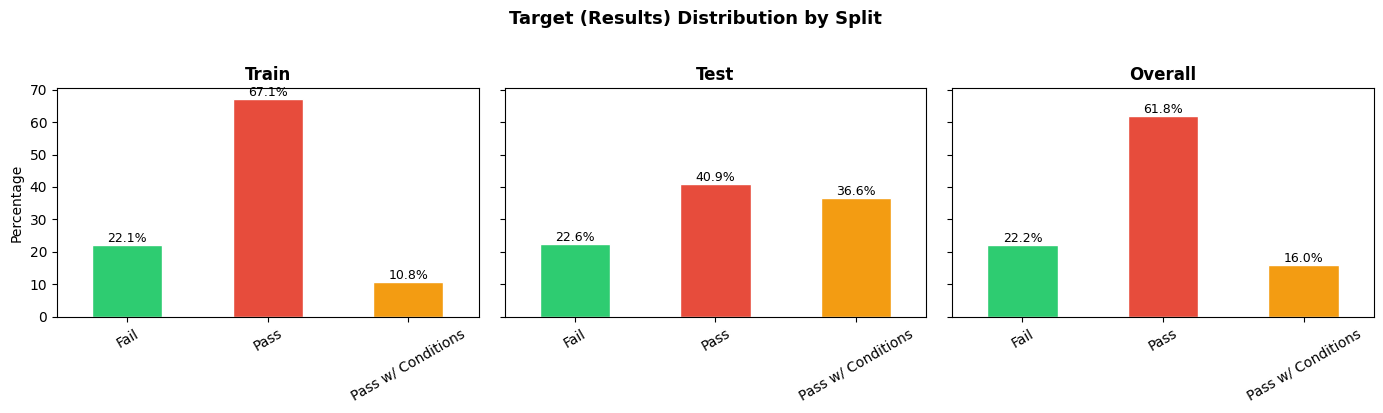

In [7]:
# Visual comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (subset, title) in zip(axes, [
    (df_train, 'Train'),
    (df_test,  'Test'),
    (df,       'Overall'),
]):
    pcts = subset[TARGET_COL].value_counts(normalize=True).mul(100)
    pcts.sort_index().plot.bar(ax=ax, color=['#2ecc71', '#e74c3c', '#f39c12'], edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Percentage' if ax == axes[0] else '')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.1f}%',
                    (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=9)

fig.suptitle('Target (Results) Distribution by Split', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 6 · Leakage checks

In [8]:
# Check 1: No shared Inspection IDs between train and test
shared_ids = set(df_train[ID_COL]) & set(df_test[ID_COL])
print(f'Shared Inspection IDs : {len(shared_ids)}')
assert len(shared_ids) == 0, f'Leakage: {len(shared_ids)} Inspection IDs appear in both splits!'

# Check 2: Train + Test = Original (no rows lost or duplicated)
assert len(df_train) + len(df_test) == len(df), \
    f'Row mismatch: {len(df_train)} + {len(df_test)} ≠ {len(df)}'

# Check 3: Date boundary integrity
print(f'Train date range : {df_train[DATE_COL].min().date()}  ->  {df_train[DATE_COL].max().date()}')
print(f'Test  date range : {df_test[DATE_COL].min().date()}  ->  {df_test[DATE_COL].max().date()}')

print('\nAll leakage checks passed.')

Shared Inspection IDs : 0
Train date range : 2010-01-04  ->  2017-08-30
Test  date range : 2017-08-31  ->  2019-12-04

All leakage checks passed.


## 7 · Export

In [9]:
TRAIN_CSV.parent.mkdir(parents=True, exist_ok=True)

df_train.to_csv(TRAIN_CSV, index=False)
df_train.to_parquet(TRAIN_PARQ, index=False)

df_test.to_csv(TEST_CSV, index=False)
df_test.to_parquet(TEST_PARQ, index=False)

print(f'Saved train -> {TRAIN_CSV}  ({TRAIN_CSV.stat().st_size / 1e6:.1f} MB csv)')
print(f'               {TRAIN_PARQ}  ({TRAIN_PARQ.stat().st_size / 1e6:.1f} MB parquet)')
print(f'Saved test  -> {TEST_CSV}  ({TEST_CSV.stat().st_size / 1e6:.1f} MB csv)')
print(f'               {TEST_PARQ}  ({TEST_PARQ.stat().st_size / 1e6:.1f} MB parquet)')

Saved train -> ..\..\data\processed\train.csv  (217.8 MB csv)
               ..\..\data\processed\train.parquet  (55.8 MB parquet)
Saved test  -> ..\..\data\processed\test.csv  (62.8 MB csv)
               ..\..\data\processed\test.parquet  (18.2 MB parquet)


## 8 · Summary

In [10]:
summary = pd.DataFrame({
    'Split':        ['Train', 'Test', 'Total'],
    'Rows':         [len(df_train), len(df_test), len(df)],
    'Pct':          [f'{len(df_train)/len(df)*100:.1f}%', f'{len(df_test)/len(df)*100:.1f}%', '100.0%'],
    'Date Start':   [df_train[DATE_COL].min().date(), df_test[DATE_COL].min().date(), df[DATE_COL].min().date()],
    'Date End':     [df_train[DATE_COL].max().date(), df_test[DATE_COL].max().date(), df[DATE_COL].max().date()],
    'Columns':      [df_train.shape[1], df_test.shape[1], df.shape[1]],
})

print('═' * 70)
print('  SPLIT SUMMARY')
print('═' * 70)
summary

══════════════════════════════════════════════════════════════════════
  SPLIT SUMMARY
══════════════════════════════════════════════════════════════════════


,Split,Rows,Pct,Date Start,Date End,Columns
0,Train,137235,80.0%,2010-01-04,2017-08-30,58
1,Test,34366,20.0%,2017-08-31,2019-12-04,58
2,Total,171601,100.0%,2010-01-04,2019-12-04,58
